# <center>DEMs, Rasters, and related tools</center>

## What are the primary formats we use for DEMs?

On VICTOR, we use two main types of file for topographical data.

#### <center> ASCII | TIFF/GeoTIFF </center>

The former is readable by all of us, and has no additional/hidden information. If a need for multiple bands or a specific projection are required, additional files must be proved.<br/>The latter is binary encoded, so we cannot read it like normal text, and has additional parameters/properties set in the file.

In [1]:
import rasterio as rio
import rioxarray as rxr
import xarray as xr
import sys
import pyproj
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
sys.path.insert(0, "/home/jovyan/shared/Libraries")
import victor
import leafmap

### First, let's pick a volcano, and download a DEM for it.

In [4]:
lon = -22.2725

lat = 63.905

### We need to determine the UTM coordinates of the volcano. Let's change the projection/CRS.

In [5]:
myProj = pyproj.Proj("+proj=utm +zone=27 +ellps=WGS84 +datum=WGS84 +units=m")

utm_east, utm_north = myProj(lon,lat)
print(utm_east,utm_north)

437551.1823970124 7087050.940733297


## Now, we can use the VICTOR library to download a DEM.

### For the sake of this problem, set bounds 2 km out from the crater on each side. Use the Copericus dataset (code COP30) for the download.

In [6]:
victor.download_dem(lat+.02,lat-.02,lon+.02,lon-.02,"ascii","COP30")

DEM downloaded as DEM_63N_63S_-22W_-22E_COP30_21062024.asc


In [ ]:
victor.download_dem_utm(utm_north+2000,utm_north-2000,utm_east+2000,utm_east-2000, nw_zone='27N',se_zone='27N',dataset="COP30", outputFormat="ascii")

### Recently, we've also implemented a higher resolution US focused function using USGS data.

In [ ]:
victor.download_dem_usgs(40.288, 40.234, -105.583, -105.673, "ascii", '10m')

The files download in latitude/longitude, so lets convert to UTM.

In [ ]:
victor.dem_to_utm(infile=filename, outfile="opentopo.asc")

## Now, we can take a brief look behind the scenes.
https://opentopography.org/

https://portal.opentopography.org/apidocs/#/

## Next, we can plot the DEM we just downloaded.

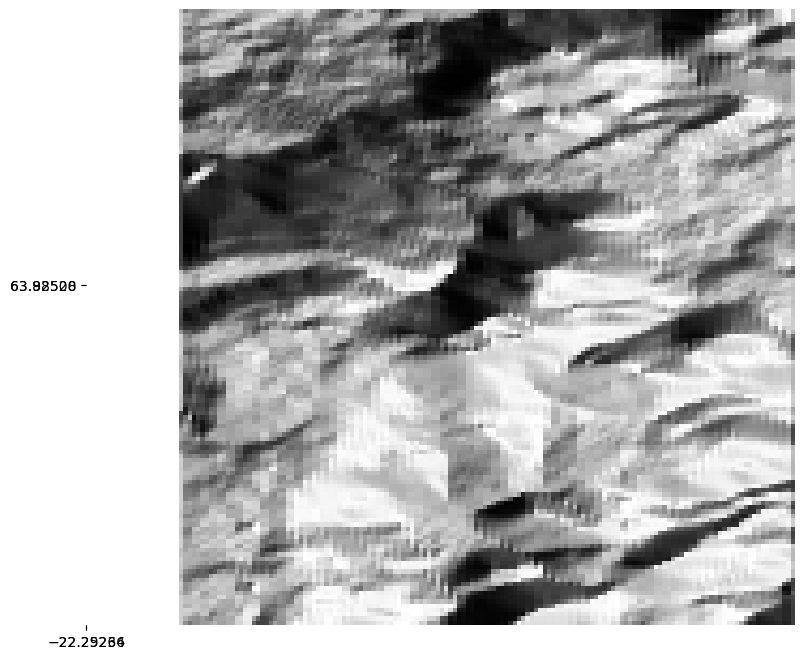

In [9]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.epsg(32627))
victor.plot_dem("DEM_63N_63S_-22W_-22E_COP30_21062024.asc",fig,ax,epsg=32627)

In [2]:
m = leafmap.Map()
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [11]:
bounds = m.user_roi_bounds()

In [12]:
victor.download_dem(bounds[3],bounds[1],bounds[2],bounds[0],"ascii","COP30")

DEM downloaded as DEM_-12N_-13S_-74W_-74E_COP30_21062024.asc


In [8]:
m = leafmap.Map()
m.add_xyz_service("qms.Google Satellite Hybrid")
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…